## 机器学习与深度学习优化算法体系专题

### 摘要 (Abstract)

在机器学习与深度学习领域，优化算法的目标是寻找模型参数 $\theta$，使得损失函数 $L(\theta)$ 最小化。根据求解策略的不同，优化算法可划分为**解析法（Analytical Methods）**与**数值分析法（Numerical Methods）**。解析法追求通过数学闭式解（Closed-form Solution）一步到位，但在深度学习的高维非线性空间中受限于计算复杂度和非凸性。数值分析法则通过迭代逼近，从二阶牛顿法降维到一阶梯度下降（GD），并演化出动量（Momentum）与自适应（Adaptive）等变体。本文将系统性地梳理这一体系，阐述各阶段算法的演进动机与应用场景。



### 一、 优化算法体系概览

优化算法的底层逻辑在于如何处理目标函数的导数信息（梯度）。其分类标准主要依据是否依赖迭代过程以及利用了几阶导数信息。

| 分类层级 | 求解策略 | 核心逻辑 | 典型算法 |
| :--- | :--- | :--- | :--- |
| **解析法** | 闭式求解 | 令 $\nabla L(\theta) = 0$ 直接求根 | 正规方程 (Normal Equation), KKT 条件 |
| **数值分析法** | 迭代搜索 | $\theta_{t+1} = \theta_t + \Delta \theta$ 逐步逼近 | 梯度下降, 牛顿法, 拟牛顿法 |

### 二、 解析法：理论基石及其局限性

解析法的核心在于利用微积分原理，通过代数变换直接锁定平稳点。

#### 2.1 典型应用：正规方程 (Normal Equation)
对于线性回归模型 $y = X\theta + \epsilon$，其最小二乘损失函数的解析解为：
$$\theta = (X^TX)^{-1}X^Ty$$

#### 2.2 深度学习弃用解析法的原因
1.  **非线性障碍**：神经网络中的激活函数（ReLU, Sigmoid）使得损失函数的导数方程成为复杂的超越方程，不存在代数闭式解。
2.  **计算复杂度**：矩阵求逆 $(X^TX)^{-1}$ 的复杂度为 $O(M^3)$，$M$ 为参数量。在千万级参数的模型中，内存与算力均无法支撑。
3.  **秩亏损与病态矩阵**：高维数据常导致 $X^TX$ 不可逆或条件数过大，导致数值解极不稳定。

### 三、 数值分析法：从二阶到一阶的降维

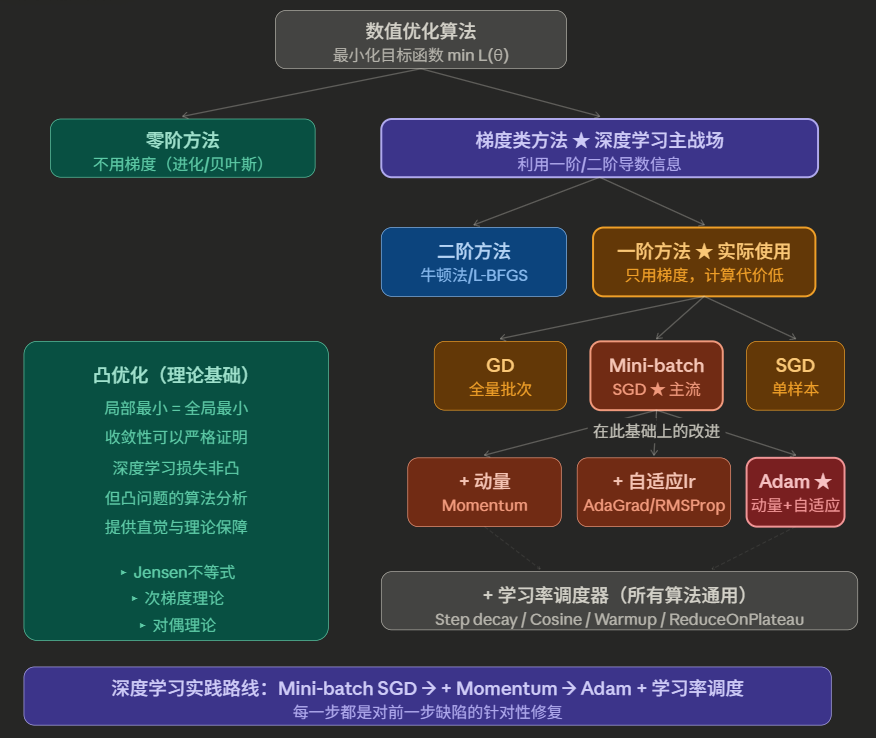

当无法通过解析法直接“看到”终点时，数值法选择在损失曲面上进行局部搜索。

#### 3.1 牛顿法（二阶数值法）
牛顿法利用二阶泰勒展开近似局部曲面：
$$\theta_{t+1} = \theta_t - H^{-1} \nabla L(\theta_t)$$
其中 $H$ 为 Hessian 矩阵。虽然收敛速度快（二阶收敛），但在深度学习中面临 **Hessian 存储成本 ($O(M^2)$)** 和 **计算逆矩阵代价** 巨大的问题，且极易陷入鞍点。

#### 3.2 梯度下降（一阶数值法）
为了适应大规模参数，深度学习退而求其次，仅利用一阶梯度信息：
$$\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)$$
其 $O(M)$ 的空间复杂度是神经网络得以训练的工程基础。

### 四、 深度学习优化器的演化路径

在进入具体算法之前，必须先理解深度学习的损失曲面与经典优化理论的核心差异。这三个挑战，直接驱动了后续每一个算法改进的动机。

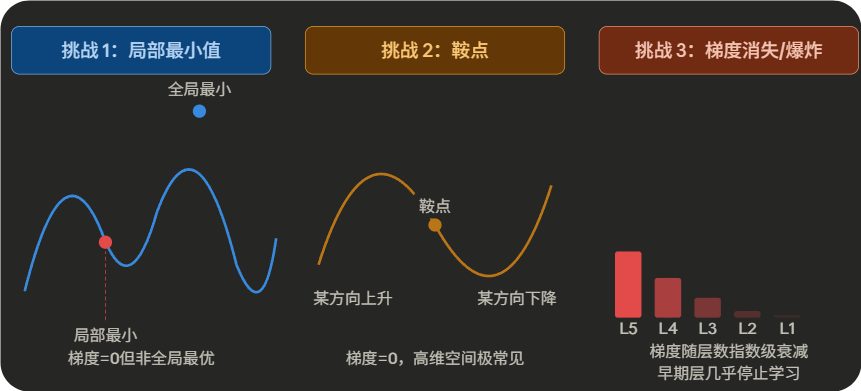

**凸优化的价值**正是在此处体现：凸函数保证"局部最小值就是全局最小值"，因此所有算法的收敛性可以被严格数学证明。深度学习损失函数虽然非凸，但研究者发现，在实践中大量的局部极小值质量相当接近全局最优（尤其是在高维空间中），真正危险的是鞍点和平坦区域。凸优化理论提供的直觉和算法框架，是分析非凸场景的基础语言。


以下逐步展示从原始梯度下降出发，每个算法如何针对性地修复前一个算法的缺陷，形成一条清晰的技术演进链。

#### 4.1 基础：批量梯度下降（GD）

每次用**全部训练样本**计算梯度，更新参数：

$$\theta \leftarrow \theta - \eta \cdot \frac{1}{N}\sum_{i=1}^{N} \nabla_\theta L_i(\theta)$$

缺陷是显而易见的：当数据集有百万条样本时，每更新一次参数就要遍历全部数据，计算代价极高，且无法实时响应数据分布的变化。

#### 4.2 修复计算代价：随机梯度下降（SGD）与 Mini-batch SGD

用**单个样本**（SGD）或**一小批样本**（Mini-batch SGD）的梯度近似替代全量梯度：

$$\theta \leftarrow \theta - \eta \cdot \nabla_\theta L_{i}(\theta) \quad \text{（随机取第 } i \text{ 个样本）}$$

Mini-batch SGD 是两者的折中，也是现代深度学习的实际标准。其中 batch size 的选取直接影响梯度估计的噪声水平和训练速度，通常取 32～512。

引入的新问题：梯度方向噪声大，在狭窄的"峡谷型"损失曲面中会剧烈震荡，收敛路径迂回。

#### 4.3 修复震荡问题：动量法（Momentum）

核心思想：给参数更新加入"惯性"，让历史梯度的方向也参与决策，而不是每步都完全跟随当前噪声梯度。

$$v_t = \beta v_{t-1} + (1-\beta)\nabla_\theta L(\theta) \qquad \theta \leftarrow \theta - \eta v_t$$

其中 $v_t$ 是梯度的指数加权移动平均，$\beta$ 通常取 0.9。效果相当于在"峡谷"中，横向震荡被历史动量相互抵消，纵向前进方向被不断累积放大，整体路径变得顺滑。

引入的新问题：所有参数共享同一个学习率 $\eta$，但实际情况中不同参数的梯度尺度差异巨大——稀疏特征（如 NLP 中的罕见词）出现频率低、梯度累积少，应当得到更大的更新步幅；高频特征则相反。

#### 4.4 修复学习率问题：AdaGrad / RMSProp

**AdaGrad** 为每个参数维护独立的累积梯度平方 $s_t$，并用它来缩放学习率：

$$s_t = s_{t-1} + g_t^2 \qquad \theta \leftarrow \theta - \frac{\eta}{\sqrt{s_t + \epsilon}} g_t$$

参数更新越频繁，$s_t$ 越大，有效学习率越小；冷门参数的 $s_t$ 较小，学习率较大，正好弥补了稀疏梯度的问题。

AdaGrad 的缺陷：$s_t$ 单调递增，训练后期有效学习率趋近于零，模型停止学习。

**RMSProp** 用指数加权移动平均替代历史梯度的全量累积，让 $s_t$ 保持动态：

$$s_t = \gamma s_{t-1} + (1-\gamma) g_t^2 \qquad \theta \leftarrow \theta - \frac{\eta}{\sqrt{s_t + \epsilon}} g_t$$

$\gamma$ 通常取 0.9，近期梯度的权重更高，$s_t$ 不再单调增长，修复了 AdaGrad 的过度衰减问题。

#### 4.5 终点：Adam（Adaptive Moment Estimation）

Adam 将 Momentum（一阶矩）与 RMSProp（二阶矩）合并到一个算法中，并加入偏差修正以消除训练初期动量估计的偏差：

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t \qquad \text{（一阶矩，动量）}$$

$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2 \qquad \text{（二阶矩，自适应学习率）}$$

$$\hat{m}_t = \frac{m_t}{1-\beta_1^t} \qquad \hat{v}_t = \frac{v_t}{1-\beta_2^t} \qquad \text{（偏差修正）}$$

$$\theta \leftarrow \theta - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

默认超参数 $\beta_1 = 0.9$，$\beta_2 = 0.999$，$\epsilon = 10^{-8}$，$\eta = 10^{-3}$。Adam 在绝大多数任务上开箱即用，是工程首选。


### 五、 工程实践建议与常见误区

#### 5.1 决策框架
* **稀疏数据（如推荐系统 Embedding）**：首选 **Adam/AdaGrad**，利用其自适应特性处理低频特征。
* **计算机视觉（CV）精度追求**：首选 **SGD + Momentum**，虽然收敛慢，但其寻找的极小值通常更“平坦”，泛化性能更好。
* **大模型（NLP/Transformer）**：首选 **AdamW + Warmup**，确保训练初期的稳定性。

#### 5.2 核心误区提示
* **陷阱 1：梯度为 0 就是最优解**。在深度学习中，梯度为 0 的点极有可能是**鞍点**而非极小值点。
* **陷阱 2：学习率越小越稳**。过小的学习率会导致模型陷入局部平坦区域无法跳出，配合 **Cosine Annealing（余弦退火）** 往往比恒定学习率效果更好。
* **陷阱 3：Adam 优于一切**。Adam 在某些场景下存在不收敛或泛化差的问题，甚至可能不如经过精细调参的 SGD。

### 六、 小结

优化算法体系是从数学上的**解析精确解**向工程上的**数值近似解**妥协的过程。在深度学习中，我们通过放弃昂贵的二阶 Hessian 信息，转而使用高效的一阶梯度，并通过动量和自适应技术，在复杂的非凸高维空间中寻找“足够好”的局部最优解。理解这一演化过程，有助于我们在面对不同规模、不同稀疏度的数据集时，做出最合理的算法选择。

---

#### **举例子**

面试官给出 $y = \sigma(x)$（其中 $\sigma$ 为 sigmoid），已知 $y$，求 $x$。

这道题实际上有两层考法：

**考法 A（解析法）**：这个函数是单调可逆的，直接取 logit：

$$x = \ln\frac{y}{1-y}$$

**考法 B（梯度下降/函数逼近）**：假装不知道逆函数，把它转化为一个优化问题，用迭代法求解。面试官想考察的正是这个——你是否理解"逼近"的本质。

#### 如何用梯度下降求解？

**第一步：构造损失函数。** 将"找 $x$ 使 $\sigma(x) \approx y$"转化为最小化：

$$L(x) = \bigl(\sigma(x) - y\bigr)^2$$

**第二步：求梯度。** 对 $x$ 求导：

$$\frac{dL}{dx} = 2\bigl(\sigma(x) - y\bigr) \cdot \sigma(x)\bigl(1 - \sigma(x)\bigr)$$

其中 $\sigma'(x) = \sigma(x)(1-\sigma(x))$ 是 sigmoid 导数的经典结论，面试中必须能直接写出。

**第三步：梯度下降迭代。**

$$x_{t+1} = x_t - \eta \cdot \frac{dL}{dx}\bigg|_{x=x_t}$$

```python


In [11]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def solve_by_gradient_descent(y_target, eta=0.1, steps=1501):
    x = 0.0  # 初始化（任意值均可，因为损失函数是凸的）
    for i in range(steps):
        sig = sigmoid(x)
        grad = 2 * (sig - y_target) * sig * (1 - sig)
        x -= eta * grad
        if i % 500 == 0:
            print(f"step {i:3d}: x={x:.6f}, σ(x)={sigmoid(x):.6f}, loss={( sigmoid(x)-y_target)**2:.2e}")
    return x

# 验证：令 y=0.8，解析解为 ln(0.8/0.2) = ln(4) ≈ 1.3863
x_solved = solve_by_gradient_descent(0.8)
print(f"\n解析解: {math.log(0.8/0.2):.6f}")
print(f"梯度下降解: {x_solved:.6f}")

step   0: x=0.015000, σ(x)=0.503750, loss=8.78e-02
step 500: x=1.338294, σ(x)=0.792209, loss=6.07e-05
step 1000: x=1.382751, σ(x)=0.799432, loss=3.22e-07
step 1500: x=1.386023, σ(x)=0.799957, loss=1.88e-09

解析解: 1.386294
梯度下降解: 1.386023
